In [ ]:
 from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
base_path = "/content/drive/MyDrive/Colab Notebooks/ML"

In [ ]:
!ls "/content/drive/MyDrive/Colab Notebooks/ML"

metadata.json	   MLprojPart2.ipynb  svg_tokenizer.json  train_tokens.pt
MLprojPart1.ipynb  part2Ish.ipynb     test_tokens.pt	  val_tokens.pt


In [ ]:
import os

print(os.listdir(base_path))

['svg_tokenizer.json', 'train_tokens.pt', 'metadata.json', 'val_tokens.pt', 'test_tokens.pt', 'MLprojPart1.ipynb', 'MLprojPart2.ipynb', 'part2Ish.ipynb']


In [ ]:
from tokenizers import Tokenizer

tokenizer = Tokenizer.from_file(base_path + "/svg_tokenizer.json")

print(tokenizer.get_vocab_size())

4000


In [ ]:
import torch

train_tokens = torch.load(base_path + "/train_tokens.pt")
val_tokens   = torch.load(base_path + "/val_tokens.pt")
test_tokens  = torch.load(base_path + "/test_tokens.pt")

In [ ]:
train_lens = [len(x) for x in train_tokens]
val_lens   = [len(x) for x in val_tokens]
test_lens  = [len(x) for x in test_tokens]

train_total = sum(train_lens) # is this > 100M
val_total   = sum(val_lens)
test_total  = sum(test_lens)

print("Train tokens:", train_total)
print("Val tokens:", val_total)
print("Test tokens:", test_total)

Train tokens: 130335440
Val tokens: 1349726
Test tokens: 1336593


## Part 2.1

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import random, math, time
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
class TinyConfig:
    block_size = 256
    vocab_size = 4000

    n_layer = 4
    n_head = 4
    n_embd = 128

    dropout = 0.1
    ff_mult = 4

In [ ]:
class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0

        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd)

        self.n_head = config.n_head
        self.dropout = nn.Dropout(config.dropout)

        self.register_buffer(
            "bias",
            torch.tril(torch.ones(config.block_size, config.block_size))
            .view(1, 1, config.block_size, config.block_size)
        )

    def forward(self, x):
        B, T, C = x.size()
        qkv = self.c_attn(x)
        q, k, v = qkv.split(C, dim=2)

        head_size = C // self.n_head

        q = q.view(B, T, self.n_head, head_size).transpose(1, 2)
        k = k.view(B, T, self.n_head, head_size).transpose(1, 2)
        v = v.view(B, T, self.n_head, head_size).transpose(1, 2)

        att = (q @ k.transpose(-2, -1)) / (head_size ** 0.5)
        att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float("-inf"))
        att = F.softmax(att, dim=-1)
        att = self.dropout(att)

        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)

        return self.c_proj(y)


In [ ]:
class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln1 = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln2 = nn.LayerNorm(config.n_embd)

        self.mlp = nn.Sequential(
            nn.Linear(config.n_embd, config.ff_mult * config.n_embd),
            nn.GELU(),
            nn.Linear(config.ff_mult * config.n_embd, config.n_embd),
            nn.Dropout(config.dropout),
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x


In [ ]:
class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.tok_emb = nn.Embedding(config.vocab_size, config.n_embd)
        self.pos_emb = nn.Embedding(config.block_size, config.n_embd)

        self.blocks = nn.Sequential(*[Block(config) for _ in range(config.n_layer)])
        self.ln_f = nn.LayerNorm(config.n_embd)
        self.head = nn.Linear(config.n_embd, config.vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        pos = torch.arange(0, T, device=idx.device)

        x = self.tok_emb(idx) + self.pos_emb(pos)[None, :, :]
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.head(x)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))

        return logits, loss

In [ ]:
def get_batch(tokens, batch_size, block_size):
    x = torch.zeros((batch_size, block_size), dtype=torch.long)
    y = torch.zeros((batch_size, block_size), dtype=torch.long)

    for i in range(batch_size):
        doc = random.choice(tokens)
        while len(doc) <= block_size + 1:
            doc = random.choice(tokens)

        start = random.randint(0, len(doc) - block_size - 1)
        chunk = doc[start:start + block_size + 1]

        x[i] = torch.tensor(chunk[:-1])
        y[i] = torch.tensor(chunk[1:])

    return x, y


In [ ]:
@torch.no_grad()
def evaluate(model, val_tokens, config, steps=50):
    device = next(model.parameters()).device

    model.eval()
    losses = []

    for _ in range(steps):
        x, y = get_batch(val_tokens, 16, config.block_size)
        x, y = x.to(device), y.to(device)

        _, loss = model(x, y)
        losses.append(loss.item())

    model.train()
    return sum(losses) / len(losses)

In [ ]:
def get_lr(step, max_steps, base_lr, warmup_steps):
    if step < warmup_steps:
        return base_lr * step / warmup_steps
    else:
        progress = (step - warmup_steps) / (max_steps - warmup_steps)
        return base_lr * 0.5 * (1 + math.cos(math.pi * progress))

In [ ]:
def train_tiny_lr(lr, train_tokens, val_tokens, config):
    device = "cuda" if torch.cuda.is_available() else "cpu"

    model = GPT(config).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.1)

    steps = 2000
    warmup_steps = int(0.1 * steps)

    val_history = []

    for step in range(steps):
        cur_lr = get_lr(step, steps, lr, warmup_steps)
        for pg in optimizer.param_groups:
            pg['lr'] = cur_lr

        x, y = get_batch(train_tokens, 32, config.block_size)
        x, y = x.to(device), y.to(device)

        _, loss = model(x, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if step % 200 == 0:
            val_loss = evaluate(model, val_tokens, config)
            val_history.append(val_loss)
            print(f"LR {lr:.1e} | step {step} | val {val_loss:.4f}")

    final_val = evaluate(model, val_tokens, config)
    return final_val, val_history


In [ ]:
config = TinyConfig()

lrs = [1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3, 5e-3]

results = {}

for lr in lrs:
    print("\n====================")
    print("Testing LR:", lr)

    val_loss, curve = train_tiny_lr(lr, train_tokens, val_tokens, config)
    results[lr] = (val_loss, curve)



Testing LR: 1e-05
LR 1.0e-05 | step 0 | val 8.4631
LR 1.0e-05 | step 200 | val 7.8443
LR 1.0e-05 | step 400 | val 6.3622
LR 1.0e-05 | step 600 | val 5.6651
LR 1.0e-05 | step 800 | val 5.2105
LR 1.0e-05 | step 1000 | val 4.8898
LR 1.0e-05 | step 1200 | val 4.6655
LR 1.0e-05 | step 1400 | val 4.5268
LR 1.0e-05 | step 1600 | val 4.4714
LR 1.0e-05 | step 1800 | val 4.4326

Testing LR: 3e-05
LR 3.0e-05 | step 0 | val 8.5079
LR 3.0e-05 | step 200 | val 6.3131
LR 3.0e-05 | step 400 | val 4.4729
LR 3.0e-05 | step 600 | val 3.5858
LR 3.0e-05 | step 800 | val 3.0277
LR 3.0e-05 | step 1000 | val 2.6983
LR 3.0e-05 | step 1200 | val 2.4970
LR 3.0e-05 | step 1400 | val 2.4092
LR 3.0e-05 | step 1600 | val 2.3532
LR 3.0e-05 | step 1800 | val 2.3309

Testing LR: 0.0001
LR 1.0e-04 | step 0 | val 8.3702
LR 1.0e-04 | step 200 | val 4.2695
LR 1.0e-04 | step 400 | val 2.3134
LR 1.0e-04 | step 600 | val 1.9580
LR 1.0e-04 | step 800 | val 1.8787
LR 1.0e-04 | step 1000 | val 1.8326
LR 1.0e-04 | step 1200 | va

In [ ]:
best_lr = min(results, key=lambda x: results[x][0])
print("\nBEST LR:", best_lr)


BEST LR: 0.005


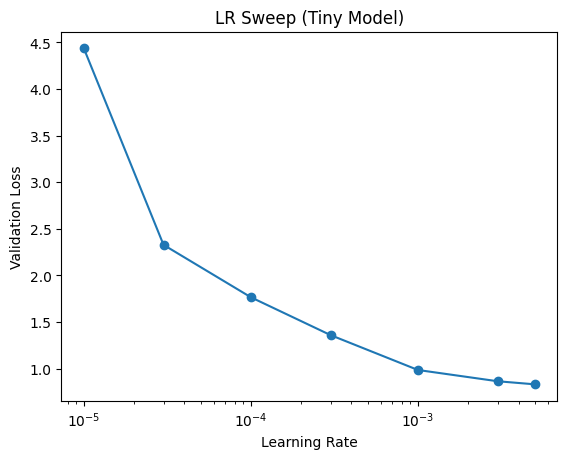

In [ ]:
lrs_sorted = sorted(results.keys())
final_losses = [results[lr][0] for lr in lrs_sorted]

plt.figure()
plt.xscale("log")
plt.plot(lrs_sorted, final_losses, marker="o")
plt.xlabel("Learning Rate")
plt.ylabel("Validation Loss")
plt.title("LR Sweep (Tiny Model)")
plt.show()

## Part 2.2-2.4

In [ ]:
class ModelConfig:
    def __init__(self, d_model, n_layer, n_head):
        self.block_size = 256
        self.vocab_size = 4000

        self.n_embd = d_model
        self.n_layer = n_layer
        self.n_head = n_head

        self.dropout = 0.1
        self.ff_mult = 4


model_configs = {
    "tiny":   ModelConfig(128, 4, 4),
    "small":  ModelConfig(192, 6, 6),
    "medium": ModelConfig(384, 6, 6),
    "large":  ModelConfig(512, 10, 8),
    "xl":     ModelConfig(768, 12, 12),
}

In [ ]:
def train_model(name, config, train_tokens, val_tokens, lr):

    device = "cuda" if torch.cuda.is_available() else "cpu"

    model = GPT(config).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.1)

    batch_size = 32
    block_size = config.block_size

    tokens_per_step = batch_size * block_size
    total_tokens = sum(len(x) for x in train_tokens)

    steps = total_tokens // tokens_per_step
    warmup_steps = int(0.05 * steps)

    print(f"{name}: {steps} steps (1 epoch)")

    train_losses = []
    val_losses = []

    if device == "cuda":
        torch.cuda.reset_peak_memory_stats()

    start = time.time()

    for step in range(steps):

        cur_lr = get_lr(step, steps, lr, warmup_steps)
        for pg in optimizer.param_groups:
            pg['lr'] = cur_lr

        x, y = get_batch(train_tokens, batch_size, block_size)
        x, y = x.to(device), y.to(device)

        _, loss = model(x, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        if step % 500 == 0:
            val_loss = evaluate(model, val_tokens, config)
            val_losses.append(val_loss)
            print(f"{name} | step {step} | val {val_loss:.4f}")

    end = time.time()

    epoch_time = end - start
    tokens_processed = steps * tokens_per_step
    throughput = tokens_processed / epoch_time

    max_mem = (
        torch.cuda.max_memory_allocated() / 1e9
        if device == "cuda" else 0
    )

    final_val = evaluate(model, val_tokens, config)

    return {
        "model": model,
        "params": sum(p.numel() for p in model.parameters()),
        "final_val": final_val,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "time": epoch_time,
        "throughput": throughput,
        "memory": max_mem
    }

In [ ]:
name = "tiny"
config = model_configs[name]

result_tiny = train_model(
    name, config, train_tokens, val_tokens, best_lr
)

tiny: 15910 steps (1 epoch)
tiny | step 0 | val 8.5282
tiny | step 500 | val 1.2871
tiny | step 1000 | val 0.9409
tiny | step 1500 | val 0.8412
tiny | step 2000 | val 0.8123
tiny | step 2500 | val 0.7892
tiny | step 3000 | val 0.7242
tiny | step 3500 | val 0.6877
tiny | step 4000 | val 0.6879
tiny | step 4500 | val 0.6683
tiny | step 5000 | val 0.6772
tiny | step 5500 | val 0.6650
tiny | step 6000 | val 0.6329
tiny | step 6500 | val 0.6204
tiny | step 7000 | val 0.6173
tiny | step 7500 | val 0.6246
tiny | step 8000 | val 0.6097
tiny | step 8500 | val 0.5863
tiny | step 9000 | val 0.5965
tiny | step 9500 | val 0.5827
tiny | step 10000 | val 0.5831
tiny | step 10500 | val 0.5847
tiny | step 11000 | val 0.5606
tiny | step 11500 | val 0.5570
tiny | step 12000 | val 0.5593
tiny | step 12500 | val 0.5425
tiny | step 13000 | val 0.5415
tiny | step 13500 | val 0.5372
tiny | step 14000 | val 0.5532
tiny | step 14500 | val 0.5488
tiny | step 15000 | val 0.5485
tiny | step 15500 | val 0.5409


In [ ]:
name = "small"
config = model_configs[name]

result_small = train_model(
    name, config, train_tokens, val_tokens, best_lr
)

small: 15910 steps (1 epoch)
small | step 0 | val 8.4610
small | step 500 | val 1.0795
small | step 1000 | val 0.8927
small | step 1500 | val 0.7637
small | step 2000 | val 0.7289
small | step 2500 | val 0.7108
small | step 3000 | val 0.6639
small | step 3500 | val 0.6517
small | step 4000 | val 0.6305
small | step 4500 | val 0.6307
small | step 5000 | val 0.6186
small | step 5500 | val 0.6109
small | step 6000 | val 0.6150
small | step 6500 | val 0.6065
small | step 7000 | val 0.5989
small | step 7500 | val 0.5670
small | step 8000 | val 0.5898
small | step 8500 | val 0.5749
small | step 9000 | val 0.5763
small | step 9500 | val 0.5552
small | step 10000 | val 0.5472
small | step 10500 | val 0.5386
small | step 11000 | val 0.5349
small | step 11500 | val 0.5307
small | step 12000 | val 0.5220
small | step 12500 | val 0.5103
small | step 13000 | val 0.5173
small | step 13500 | val 0.5054
small | step 14000 | val 0.5048
small | step 14500 | val 0.4946
small | step 15000 | val 0.5083
sma

In [ ]:
name = "medium"
config = model_configs[name]

result_medium = train_model(
    name, config, train_tokens, val_tokens, best_lr
)

medium: 15910 steps (1 epoch)
medium | step 0 | val 8.4815
medium | step 500 | val 0.9855
medium | step 1000 | val 0.8878
medium | step 1500 | val 0.7648
medium | step 2000 | val 0.7428
medium | step 2500 | val 0.7077
medium | step 3000 | val 0.6844
medium | step 3500 | val 0.6700
medium | step 4000 | val 0.6454
medium | step 4500 | val 0.6419
medium | step 5000 | val 0.6259
medium | step 5500 | val 0.6034
medium | step 6000 | val 0.6052
medium | step 6500 | val 0.5976
medium | step 7000 | val 0.5834
medium | step 7500 | val 0.5817
medium | step 8000 | val 0.5638
medium | step 8500 | val 0.5435
medium | step 9000 | val 0.5374
medium | step 9500 | val 0.5617
medium | step 10000 | val 0.5453
medium | step 10500 | val 0.5296
medium | step 11000 | val 0.5188
medium | step 11500 | val 0.5233
medium | step 12000 | val 0.5063
medium | step 12500 | val 0.5109
medium | step 13000 | val 0.5003
medium | step 13500 | val 0.4876
medium | step 14000 | val 0.4832
medium | step 14500 | val 0.4805
medi

In [ ]:
name = "large"
config = model_configs[name]

result_large = train_model(
    name, config, train_tokens, val_tokens, best_lr
)

large: 15910 steps (1 epoch)
large | step 0 | val 8.4643
large | step 500 | val 1.9243
large | step 1000 | val 1.9944
large | step 1500 | val 2.0692
large | step 2000 | val 2.2676
large | step 2500 | val 2.5042
large | step 3000 | val 2.4247
large | step 3500 | val 2.4895
large | step 4000 | val 2.6731
large | step 4500 | val 2.8019
large | step 5000 | val 2.6719
large | step 5500 | val 2.3481
large | step 6000 | val 2.5652
large | step 6500 | val 2.6589
large | step 7000 | val 2.2939
large | step 7500 | val 1.6488
large | step 8000 | val 1.0420
large | step 8500 | val 0.9796
large | step 9000 | val 0.8972
large | step 9500 | val 0.8779
large | step 10000 | val 0.8312
large | step 10500 | val 0.7907
large | step 11000 | val 0.7868
large | step 11500 | val 0.7550
large | step 12000 | val 0.7544
large | step 12500 | val 0.7207
large | step 13000 | val 0.7031
large | step 13500 | val 0.7106
large | step 14000 | val 0.6878
large | step 14500 | val 0.6929
large | step 15000 | val 0.6656
lar

In [ ]:
name = "xl"
config = model_configs[name]

result_xl = train_model(
    name, config, train_tokens, val_tokens, best_lr
)

xl: 15910 steps (1 epoch)
xl | step 0 | val 8.4863
xl | step 500 | val 1.7424
xl | step 1000 | val 2.0752
xl | step 1500 | val 2.1738
xl | step 2000 | val 2.1721
xl | step 2500 | val 2.5520
xl | step 3000 | val 2.4623
xl | step 3500 | val 2.4516
xl | step 4000 | val 2.6312
xl | step 4500 | val 2.3852
xl | step 5000 | val 2.0548
xl | step 5500 | val 2.0206
xl | step 6000 | val 2.0693
xl | step 6500 | val 2.0170
xl | step 7000 | val 2.2025
xl | step 7500 | val 1.8308
xl | step 8000 | val 1.1002
xl | step 8500 | val 0.9916
xl | step 9000 | val 0.9331
xl | step 9500 | val 0.8609
xl | step 10000 | val 0.8255
xl | step 10500 | val 0.7935
xl | step 11000 | val 0.7366
xl | step 11500 | val 0.7407
xl | step 12000 | val 0.7197
xl | step 12500 | val 0.7096
xl | step 13000 | val 0.6840
xl | step 13500 | val 0.6892
xl | step 14000 | val 0.6892
xl | step 14500 | val 0.6413
xl | step 15000 | val 0.6598
xl | step 15500 | val 0.6350


In [ ]:
results = {
    "tiny": result_tiny,
    "small": result_small,
    "medium": result_medium,
    "large": result_large,
    "xl": result_xl
}

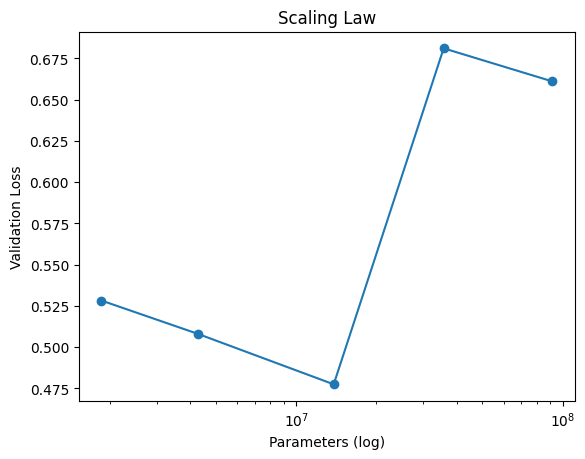

In [ ]:
params = [results[n]["params"] for n in results]
losses = [results[n]["final_val"] for n in results]

plt.figure()
plt.xscale("log")
plt.plot(params, losses, "o-")
plt.xlabel("Parameters (log)")
plt.ylabel("Validation Loss")
plt.title("Scaling Law")
plt.show()

In [ ]:
from scipy.optimize import curve_fit

def power_law(N, a, alpha, c):
    return a * (N ** (-alpha)) + c

params_np = np.array(params)
loss_np = np.array(losses)
popt, _ = curve_fit(power_law, params_np, loss_np, p0=[1.0, 0.05, 0.4], maxfev=50000)

a, alpha, c = popt
print("Scaling exponent alpha:", alpha)

Scaling exponent alpha: 900260.3118169791


/tmp/ipykernel_629/211740067.py:9: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(power_law, params_np, loss_np, maxfev=10000)


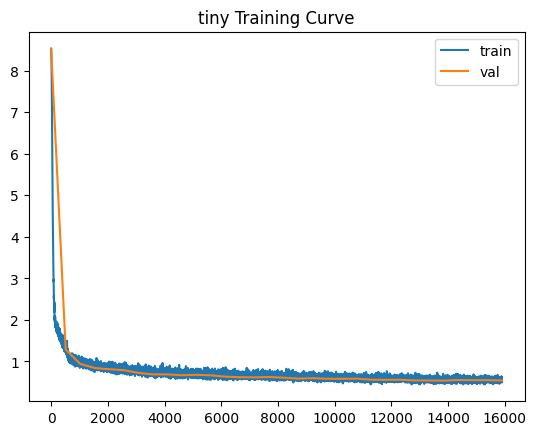

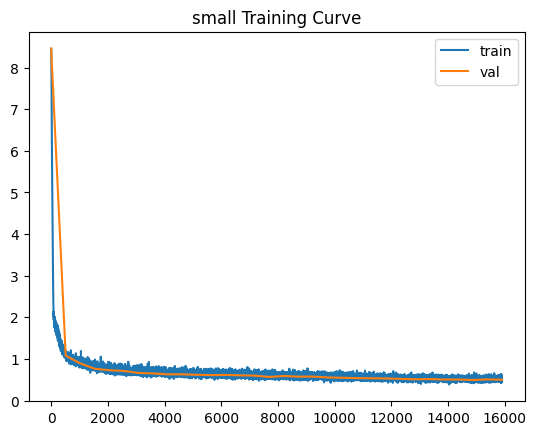

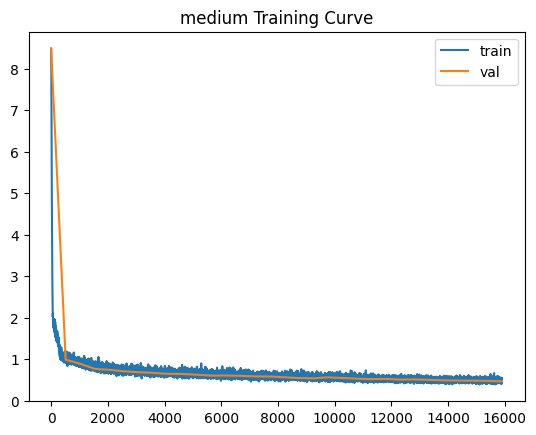

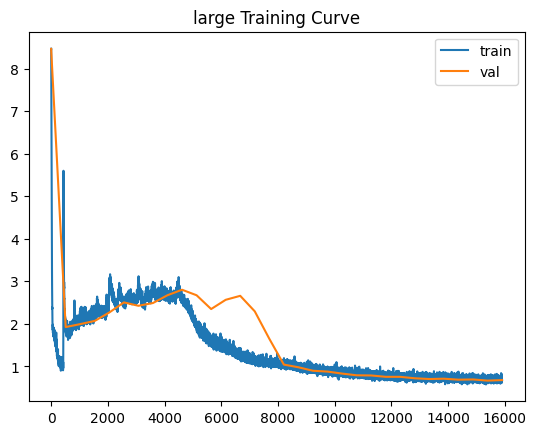

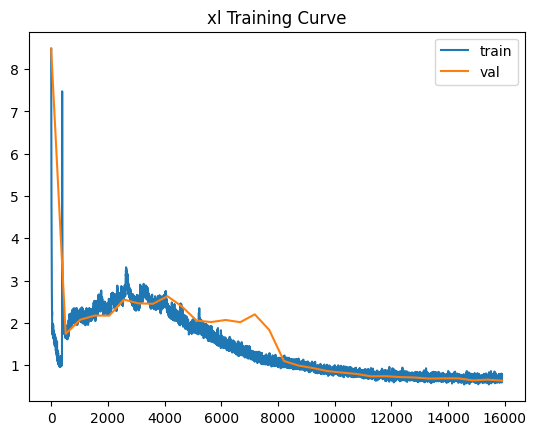

In [ ]:
for name in results:
    res = results[name]

    plt.figure()
    plt.plot(res["train_losses"], label="train")

    val_x = np.linspace(0, len(res["train_losses"]), len(res["val_losses"]))
    plt.plot(val_x, res["val_losses"], label="val")

    plt.title(f"{name} Training Curve")
    plt.legend()
    plt.show()

In [ ]:
print("\n===== RESULTS =====")
for name, res in results.items():
    print(f"{name.upper():6} | Params: {res['params']:,} | "
          f"Val Loss: {res['final_val']:.4f} | "
          f"Time: {res['time']:.1f}s | "
          f"Tok/s: {res['throughput']:.1f} | "
          f"Mem: {res['memory']:.2f} GB")


===== RESULTS =====
TINY   | Params: 1,854,112 | Val Loss: 0.5282 | Time: 269.8s | Tok/s: 483028.2
SMALL  | Params: 4,258,720 | Val Loss: 0.5081 | Time: 485.3s | Tok/s: 268571.3
MEDIUM | Params: 13,821,856 | Val Loss: 0.4774 | Time: 941.8s | Tok/s: 138382.1
LARGE  | Params: 35,755,936 | Val Loss: 0.6812 | Time: 2162.5s | Tok/s: 60269.0
XL     | Params: 91,400,608 | Val Loss: 0.6611 | Time: 5037.0s | Tok/s: 25875.4
